#Lab 4: Compare RNN vs LSTM vs GRU Performance
This notebook builds and compares Simple RNN, LSTM, and GRU models on the IMDB text classification dataset.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Load and Prepare Dataset

In [ ]:
max_features = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000


Build Models

In [ ]:
def build_model(model_type):
    model = keras.Sequential()
    model.add(layers.Embedding(max_features, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(layers.SimpleRNN(128))
    elif model_type == "LSTM":
        model.add(layers.LSTM(128))
    elif model_type == "GRU":
        model.add(layers.GRU(128))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

Train Models

In [ ]:
models = {}
histories = {}

for model_name in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_name}...")
    model = build_model(model_name)
    history = model.fit(x_train, y_train,
                        epochs=3,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)
    models[model_name] = model
    histories[model_name] = history


Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.6141 - loss: 0.6362 - val_accuracy: 0.7648 - val_loss: 0.5009
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.7607 - loss: 0.4933 - val_accuracy: 0.6388 - val_loss: 0.6187
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 82ms/step - accuracy: 0.7605 - loss: 0.4991 - val_accuracy: 0.6892 - val_loss: 0.6476

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 327ms/step - accuracy: 0.7919 - loss: 0.4403 - val_accuracy: 0.8128 - val_loss: 0.4224
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 326ms/step - accuracy: 0.8950 - loss: 0.2684 - val_accuracy: 0.8600 - val_loss: 0.3428
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 107s 341ms/step - accuracy: 0.9344 - loss: 0.1798 - val_accuracy: 0.8606 - val_loss: 0.3461

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 288ms/step - accuracy: 0.7301 - loss: 0.5174 - val_accuracy: 0.8078 - val_loss: 0.4367
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 284ms/step - accuracy:

Evaluate Models

In [ ]:
results = {}

for model_name, model in models.items():
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results[model_name] = acc
    print(f"{model_name} Test Accuracy: {acc:.4f}")

RNN Test Accuracy: 0.6883
LSTM Test Accuracy: 0.8569
GRU Test Accuracy: 0.8620


Accuracy Comparison Plot

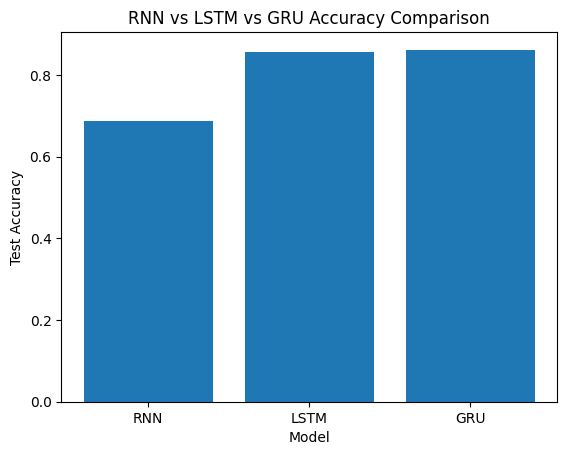

In [ ]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.show()

## Conclusion
- Simple RNN suffers from vanishing gradient problem.
- LSTM handles long-term dependencies using gates.
- GRU is computationally efficient and often performs similar to LSTM.

Typically: LSTM ≈ GRU > RNN in text classification tasks.